In [1]:
import pandas as pd
import numpy as np


In [2]:
df = pd.read_csv('housing.csv')

In [3]:
df.head(3)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY


In [4]:
df.shape

(20640, 10)

In [5]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [7]:
df.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [8]:
df.head(3)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY


In [9]:
df.dropna(axis=0,inplace=True)

In [10]:
df.isna().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [11]:
df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9034
INLAND        6496
NEAR OCEAN    2628
NEAR BAY      2270
ISLAND           5
Name: count, dtype: int64

In [12]:
df['median_house_value'].value_counts()

median_house_value
500001.0    958
137500.0    119
162500.0    116
112500.0    103
187500.0     92
           ... 
359200.0      1
51200.0       1
39800.0       1
377600.0      1
47000.0       1
Name: count, Length: 3833, dtype: int64

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [14]:
df.head(1)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY


In [15]:
df = pd.get_dummies(data=df,columns=['ocean_proximity'],drop_first=True)

In [16]:
df.head(2)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,True,False


In [17]:
X = df.drop(columns=['median_house_value'])
y = df['median_house_value']

In [18]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [19]:
lm = LinearRegression()

In [20]:
lm.fit(X_train,y_train)

LinearRegression()

In [21]:
y_pred = lm.predict(X_test)


In [22]:
y_pred

array([201882.95986766, 147279.68214383, 207796.60979846, ...,
       110229.93045317, 137315.7328207 , 169083.81714045])

In [23]:
from sklearn.metrics import r2_score

In [24]:
r2_score(y_test,y_pred)

0.6488402154431996

In [25]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000
mean,-119.570689,35.633221,28.633094,2636.504233,537.870553,1424.946949,499.433465,3.871162,206864.413155
std,2.003578,2.136348,12.591805,2185.269567,421.385070,1133.208490,382.299226,1.899291,115435.667099
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1450.000000,296.000000,787.000000,280.000000,2.563700,119500.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.536500,179700.000000
75%,-118.010000,37.720000,37.000000,3143.000000,647.000000,1722.000000,604.000000,4.744000,264700.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [26]:
df1 = df.copy()

In [27]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df1[['median_house_value']].values.reshape(-1, 1))

# Print the scaled data
print(scaled_data)


[[0.90226638]
 [0.70824656]
 [0.69505074]
 ...
 [0.15938285]
 [0.14371281]
 [0.15340349]]


In [28]:
X = df1.drop(columns=['median_house_value'])
y = df1['median_house_value']

In [29]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)



In [30]:
lm = LinearRegression()

In [31]:
lm.fit(X_train,y_train)

LinearRegression()

In [32]:
y_pred1 = lm.predict(X_test)

In [33]:
from sklearn.metrics import r2_score

In [34]:
r2_score(y_test,y_pred1)

0.6488402154431996

In [35]:
df1.head(2)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,True,False


In [36]:
from sklearn.linear_model import Lasso,Ridge

In [37]:
ll= Lasso()

In [38]:
ll.fit(X_train,y_train)

Lasso()

In [39]:
y_pred2 = ll.predict(X_test)

In [40]:
r2_score(y_test,y_pred2)

0.6488996331784942

In [41]:
rr = Ridge()

In [42]:
rr.fit(X_train,y_train)

Ridge()

In [43]:
y_pred3 = rr.predict(X_test)

In [44]:
r2_score(y_test,y_pred3)

0.6493204593787925

In [45]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,True,False,False,False
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,True,False,False,False
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,True,False,False,False
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,True,False,False,False


In [46]:
df.corr()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
longitude,1.000000,-0.924616,-0.109357,0.045480,0.069608,0.100270,0.056513,-0.015550,-0.045398,-0.055337,0.009501,-0.474714,0.046185
latitude,-0.924616,1.000000,0.011899,-0.036667,-0.066983,-0.108997,-0.071774,-0.079626,-0.144638,0.351084,-0.016662,0.358785,-0.161342
housing_median_age,-0.109357,0.011899,1.000000,-0.360628,-0.320451,-0.295787,-0.302768,-0.118278,0.106432,-0.236968,0.017105,0.256149,0.020797
total_rooms,0.045480,-0.036667,-0.360628,1.000000,0.930380,0.857281,0.918992,0.197882,0.133294,0.026477,-0.007603,-0.023647,-0.008674
total_bedrooms,0.069608,-0.066983,-0.320451,0.930380,1.000000,0.877747,0.979728,-0.007723,0.049686,-0.006463,-0.004361,-0.019873,0.000679
population,0.100270,-0.108997,-0.295787,0.857281,0.877747,1.000000,0.907186,0.005087,-0.025300,-0.019602,-0.010451,-0.061480,-0.023498
households,0.056513,-0.071774,-0.302768,0.918992,0.979728,0.907186,1.000000,0.013434,0.064894,-0.038265,-0.009119,-0.011280,0.002106
median_income,-0.015550,-0.079626,-0.118278,0.197882,-0.007723,0.005087,0.013434,1.000000,0.688355,-0.237536,-0.009281,0.056677,0.027351
median_house_value,-0.045398,-0.144638,0.106432,0.133294,0.049686,-0.025300,0.064894,0.688355,1.000000,-0.484787,0.023525,0.160526,0.140378
ocean_proximity_INLAND,-0.055337,0.351084,-0.236968,0.026477,-0.006463,-0.019602,-0.038265,-0.237536,-0.484787,1.000000,-0.010681,-0.241356,-0.262289


In [47]:
from sklearn.tree import DecisionTreeRegressor

In [48]:
dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)

DecisionTreeRegressor()

In [49]:
y_pred4 = dt.predict(X_test)

In [50]:
r2_score(y_test,y_pred4)

0.6701179837655091

In [51]:
from sklearn.ensemble import RandomForestRegressor

In [52]:
rf = RandomForestRegressor()
rf.fit(X_train, y_train)

RandomForestRegressor()

In [53]:
y_pred5 = rf.predict(X_test)

In [54]:
r2_score(y_test,y_pred5)

0.826695119098924

In [55]:
from sklearn.ensemble import GradientBoostingRegressor

In [56]:
gbr = GradientBoostingRegressor()
gbr.fit(X_train, y_train)

GradientBoostingRegressor()

In [57]:
y_pred6 = gbr.predict(X_test)

In [58]:
r2_score(y_test,y_pred6)

0.7660151432235298

In [59]:
from xgboost import XGBRegressor

In [60]:
xgb = XGBRegressor()
xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [61]:
y_pred7 = xgb.predict(X_test)

In [62]:
r2_score(y_test,y_pred7)

0.8312191448795185

In [63]:
models = [RandomForestRegressor(),XGBRegressor(),DecisionTreeRegressor(),GradientBoostingRegressor()]
r2score = []
for model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2score.append(f"{model.__class__.__name__}: {r2_score(y_test, y_pred)}")

In [64]:
r2score

['RandomForestRegressor: 0.8264125871923904',
 'XGBRegressor: 0.8312191448795185',
 'DecisionTreeRegressor: 0.6578159260089029',
 'GradientBoostingRegressor: 0.7660251526027442']

In [65]:
models = {
    "RandomForestRegressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(),
    "DecisionTreeRegressor": DecisionTreeRegressor(),
    "GradientBoostingRegressor": GradientBoostingRegressor()
}


for name, model in models.items():
    print(f"{name} default parameters:\n{model.get_params()}\n")

RandomForestRegressor default parameters:
{'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': None, 'verbose': 0, 'warm_start': False}

XGBRegressor default parameters:
{'objective': 'reg:squarederror', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': None, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': None, 'max_leaves': None, 'min_ch

In [66]:
from sklearn.model_selection import cross_val_score

In [67]:
r2score

['RandomForestRegressor: 0.8264125871923904',
 'XGBRegressor: 0.8312191448795185',
 'DecisionTreeRegressor: 0.6578159260089029',
 'GradientBoostingRegressor: 0.7660251526027442']

In [68]:
from sklearn.model_selection import GridSearchCV


In [69]:
xgb = XGBRegressor()


param_grid = {
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200, 500],
    'gamma': [0, 1, 5]
}


grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid, scoring='r2', cv=5, verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)


print("Best parameters:", grid_search.best_params_)
print("Best R² score:", grid_search.best_score_)


Fitting 5 folds for each of 108 candidates, totalling 540 fits


/opt/anaconda3/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:700: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best parameters: {'gamma': 0, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 500}
Best R² score: 0.8397614479708204


In [70]:
rgb =  RandomForestRegressor()

param_grid = {
    'n_estimators': [10, 50, 100, 200],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 5, 10]
    
}

grid_search = GridSearchCV(estimator=rgb,param_grid = param_grid,scoring = 'r2',cv=5,verbose=1,n_jobs=-1)
grid_search.fit(X_train,y_train)


print("Best parameters:", grid_search.best_params_)
print("Best R² score:", grid_search.best_score_)


Fitting 5 folds for each of 144 candidates, totalling 720 fits


/opt/anaconda3/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:700: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best R² score: 0.8170835769886736


In [71]:
dt = DecisionTreeRegressor()

param_grid = {
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 5, 10],
    'max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(estimator=dt,param_grid = param_grid,scoring='r2',cv=5,verbose=1,n_jobs=-1)
grid_search.fit(X_train, y_train)
print("Best Parameters: ", grid_search.best_params_)
print("Best Score: ", grid_search.best_score_)


Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best Parameters:  {'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 10, 'min_samples_split': 10}
Best Score:  0.6596691710983756


In [72]:
gbr = GradientBoostingRegressor()

param_grid = {
    'n_estimators': [100, 200, 300, 400, 500],
    'learning_rate': [0.1, 0.05, 0.01],
    'max_depth': [3, 5, 7, 9, 11],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 5, 10]
}

grid_search = GridSearchCV(estimator = gbr,param_grid = param_grid,cv=5,scoring='r2',verbose=1,n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best Parameters: ", grid_search.best_params_)
print("Best Score: ", grid_search.best_score_)

Fitting 5 folds for each of 675 candidates, totalling 3375 fits
Best Parameters:  {'learning_rate': 0.1, 'max_depth': 7, 'min_samples_leaf': 10, 'min_samples_split': 10, 'n_estimators': 500}
Best Score:  0.8390093312589828


In [74]:
models = [
    RandomForestRegressor(max_depth= None, min_samples_leaf = 1, min_samples_split= 2, n_estimators = 200),
    XGBRegressor(gamma = 0, learning_rate = 0.1, max_depth = 5, n_estimators = 500),
    DecisionTreeRegressor(max_depth=10, max_features='log2', min_samples_leaf=10, min_samples_split=10), 
    GradientBoostingRegressor(learning_rate=0.1, max_depth=7, min_samples_leaf=10, min_samples_split=10, n_estimators=500)
]

r2score = []
cvs = []


for model in models:
    
    model.fit(X_train, y_train)
    

    y_pred = model.predict(X_test)
    
  
    r2 = r2_score(y_test, y_pred)
    r2score.append(f"{model.__class__.__name__}: {r2}")
    

    scores = cross_val_score(model, X, y, cv=5, scoring='r2')
    cvs.append(f"{model.__class__.__name__}: {scores.mean()}")


print("R² Scores:", r2score)
print("Cross-Validation Scores:", cvs)

R² Scores: ['RandomForestRegressor: 0.8265586207635648', 'XGBRegressor: 0.8378122361265694', 'DecisionTreeRegressor: 0.6411070728074953', 'GradientBoostingRegressor: 0.8432578559027376']
Cross-Validation Scores: ['RandomForestRegressor: 0.5042193134492768', 'XGBRegressor: 0.6480924728200025', 'DecisionTreeRegressor: 0.3152123841846481', 'GradientBoostingRegressor: 0.6014785120051702']


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

Feature Importances


R² Scores: ['RandomForestRegressor: 0.8258524430852099', 'XGBRegressor: 0.8378122361265694', 'DecisionTreeRegressor: 0.7443292675463069', 'GradientBoostingRegressor: 0.8456449404855177']
Cross-Validation Scores: ['RandomForestRegressor: 0.5007484653309069', 'XGBRegressor: 0.6480924728200025', 'DecisionTreeRegressor: 0.338782869451775', 'GradientBoostingRegressor: 0.5843640033949751']


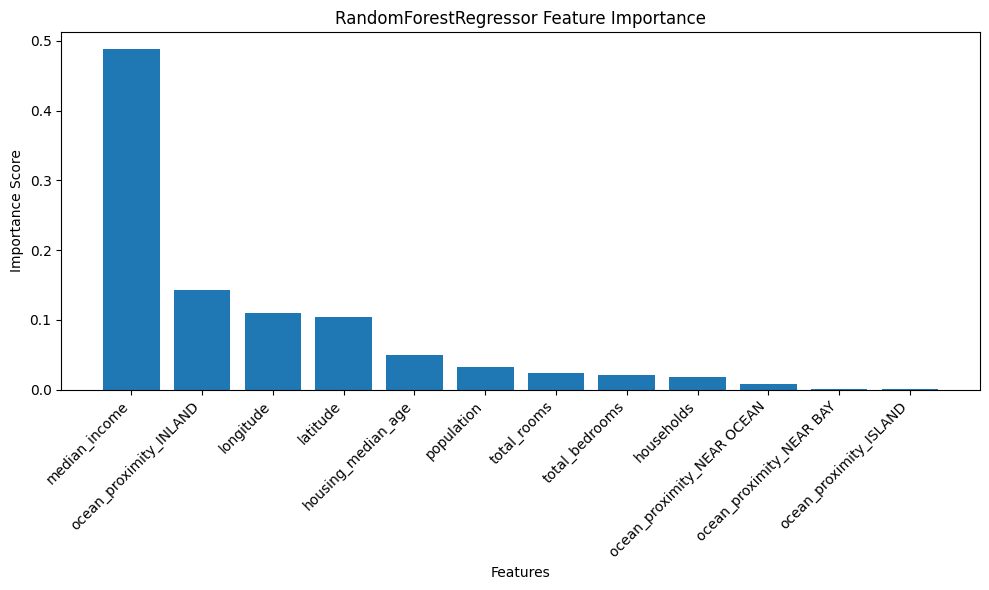

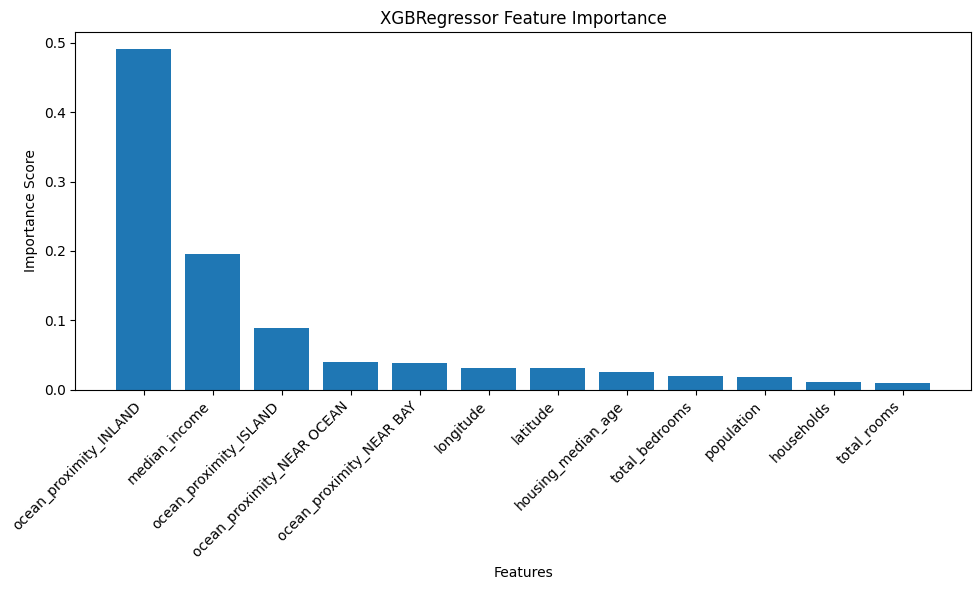

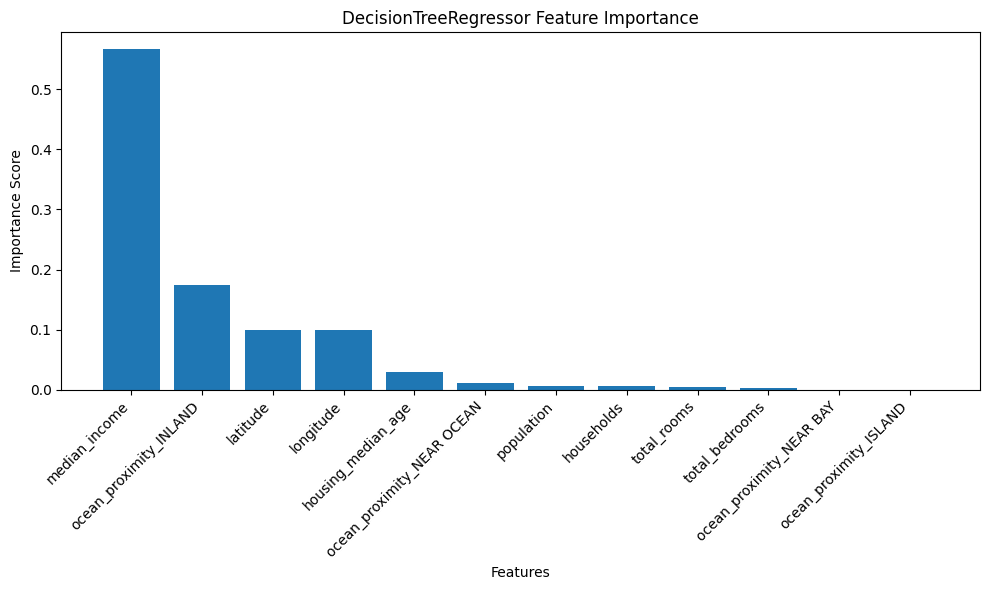

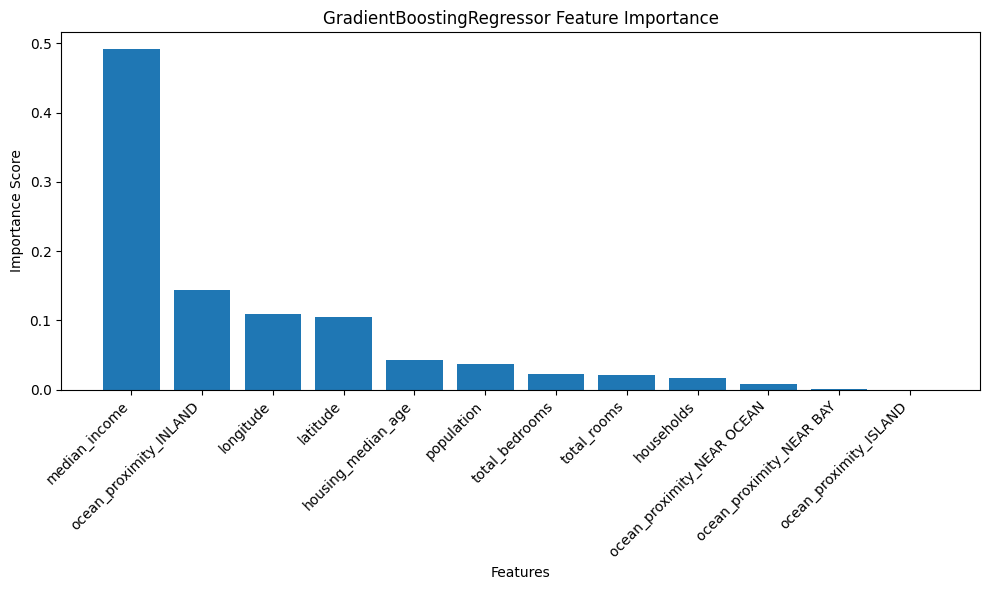

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


models = [
    RandomForestRegressor(max_depth=20, min_samples_leaf=1, min_samples_split=2, n_estimators=200),
    XGBRegressor(gamma=0, learning_rate=0.1, max_depth=5, n_estimators=500),
    DecisionTreeRegressor(max_depth=10, max_features=None, min_samples_leaf=10, min_samples_split=10), 
    GradientBoostingRegressor(learning_rate=0.05, max_depth=9, min_samples_leaf=10, min_samples_split=5, n_estimators=500)
]

r2score = []
cvs = []
feature_importance_dict = {}



for model in models:
  
    model.fit(X_train, y_train)


    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    r2score.append(f"{model.__class__.__name__}: {r2}")

    
    scores = cross_val_score(model, X, y, cv=5, scoring='r2')
    cvs.append(f"{model.__class__.__name__}: {scores.mean()}")

   
    if hasattr(model, "feature_importances_"):
        feature_importance_dict[model.__class__.__name__] = model.feature_importances_


print("R² Scores:", r2score)
print("Cross-Validation Scores:", cvs)


for model_name, importances in feature_importance_dict.items():
    sorted_idx = np.argsort(importances)[::-1] 
    plt.figure(figsize=(10, 6))
    plt.bar(range(len(importances)), importances[sorted_idx], align="center")
    plt.xticks(range(len(importances)), X_train.columns[sorted_idx], rotation=45, ha="right")
    plt.title(f"{model_name} Feature Importance")
    plt.ylabel("Importance Score")
    plt.xlabel("Features")
    plt.tight_layout()
    plt.show()


In [75]:
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [77]:
mse = mean_squared_error(y_test,y_pred7) #xgb ka hai ye
mse

2308108706.996476

In [78]:
mae = mean_absolute_error(y_test,y_pred7)
mae

31774.649880241468

In [79]:
mae2 = mean_absolute_error(y_test,y_pred6) #gbr ka hai ye
mae2

39268.587243849586

In [80]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [81]:
lr.fit(X_train,y_train)

LinearRegression()

In [82]:
y_pred8 = lr.predict(X_test)

In [83]:
r2_score(y_test,y_pred8)

0.6488402154431996

In [84]:
r2_score(y_test,y_pred7)

0.8312191448795185

In [87]:
import matplotlib.pyplot as plt
import numpy as np


models = [
    RandomForestRegressor(max_depth=20, min_samples_leaf=1, min_samples_split=2, n_estimators=200),
    XGBRegressor(gamma=0, learning_rate=0.1, max_depth=5, n_estimators=500),
    DecisionTreeRegressor(max_depth=10, max_features=None, min_samples_leaf=10, min_samples_split=10), 
    GradientBoostingRegressor(learning_rate=0.05, max_depth=9, min_samples_leaf=10, min_samples_split=5, n_estimators=500)
]

r2score = []
cvs = []
maes = []
feature_importance_dict = {}



for model in models:
  
    model.fit(X_train, y_train)


    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    r2score.append(f"{model.__class__.__name__}: {r2}")
   
    mae = mean_absolute_error(y_test,y_pred)
    maes.append(f"{model.__class__.__name__}:{mae}")

    
    scores = cross_val_score(model, X, y, cv=5, scoring='r2')
    cvs.append(f"{model.__class__.__name__}: {scores.mean()}")

   
    if hasattr(model, "feature_importances_"):
        feature_importance_dict[model.__class__.__name__] = model.feature_importances_


print("R² Scores:", r2score)
print("Cross-Validation Scores:", cvs)
print("MAE Scores:", maes)

R² Scores: ['RandomForestRegressor: 0.8268468801085076', 'XGBRegressor: 0.8378122361265694', 'DecisionTreeRegressor: 0.7443156261904191', 'GradientBoostingRegressor: 0.8449450208365594']
Cross-Validation Scores: ['RandomForestRegressor: 0.5117209604604935', 'XGBRegressor: 0.6480924728200025', 'DecisionTreeRegressor: 0.3389611182862108', 'GradientBoostingRegressor: 0.5842023565077593']
MAE Scores: ['RandomForestRegressor:31557.341164972157', 'XGBRegressor:30823.751526849614', 'DecisionTreeRegressor:39486.78624562764', 'GradientBoostingRegressor:29987.458344808194']


In [90]:
maes

['RandomForestRegressor:31557.341164972157',
 'XGBRegressor:30823.751526849614',
 'DecisionTreeRegressor:39486.78624562764',
 'GradientBoostingRegressor:29987.458344808194']

In [92]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [95]:
input_shape = X_train.shape[1]
modell = keras.Sequential([
    layers.Input(shape = (input_shape,)),
    layers.Dense(32, activation = 'relu'),
    layers.Dense(32,activation='relu'),
    layers.Dense(1)
])
    

In [96]:
modell.compile(optimizer='adam',loss = 'mean_absolute_error')


In [100]:
modell.fit(X,y,epochs=1000,batch_size=32,validation_data=(X_test,y_test))

Epoch 1/1000
639/639 ━━━━━━━━━━━━━━━━━━━━ 0s 285us/step - loss: 41834.7773 - val_loss: 41966.6523
Epoch 2/1000
639/639 ━━━━━━━━━━━━━━━━━━━━ 0s 255us/step - loss: 41200.2227 - val_loss: 41448.2109
Epoch 3/1000
639/639 ━━━━━━━━━━━━━━━━━━━━ 0s 254us/step - loss: 41731.4727 - val_loss: 41972.9648
Epoch 4/1000
639/639 ━━━━━━━━━━━━━━━━━━━━ 0s 255us/step - loss: 41813.9570 - val_loss: 42269.6328
Epoch 5/1000
639/639 ━━━━━━━━━━━━━━━━━━━━ 0s 254us/step - loss: 41684.7109 - val_loss: 43322.9922
Epoch 6/1000
639/639 ━━━━━━━━━━━━━━━━━━━━ 0s 256us/step - loss: 41897.4766 - val_loss: 41615.9141
Epoch 7/1000
639/639 ━━━━━━━━━━━━━━━━━━━━ 0s 254us/step - loss: 41840.1016 - val_loss: 43266.3906
Epoch 8/1000
639/639 ━━━━━━━━━━━━━━━━━━━━ 0s 254us/step - loss: 41843.8750 - val_loss: 41587.7617
Epoch 9/1000
639/639 ━━━━━━━━━━━━━━━━━━━━ 0s 255us/step - loss: 42079.8203 - val_loss: 43163.2500
Epoch 10/1000
639/639 ━━━━━━━━━━━━━━━━━━━━ 0s 255us/step - loss: 42373.5703 - val_loss: 45023.4922
Epoch 11/1000
639/6